In [16]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd().parent
data_path = project_root / "outputs"

df = pd.read_csv(data_path / "london_features_dataset.csv")

print(df.head())
print(df.shape)
print(df.columns.tolist())

   count_point_id direction_of_travel  count_date  hour region_name  \
0            6000                   N  2000-03-27    10      London   
1            6000                   S  2000-03-27    10      London   
2            6000                   S  2000-03-27    11      London   
3            6000                   N  2000-03-27    11      London   
4            6000                   S  2000-03-27    12      London   

  local_authority_name road_name road_category road_type   latitude  ...  \
0               Barnet        M1            TM     Major  51.587522  ...   
1               Barnet        M1            TM     Major  51.587522  ...   
2               Barnet        M1            TM     Major  51.587522  ...   
3               Barnet        M1            TM     Major  51.587522  ...   
4               Barnet        M1            TM     Major  51.587522  ...   

             timestamp  hour_of_day  day_of_week  month  year  day   lag_1  \
0  2000-03-27 10:00:00           10   

In [17]:
nodes_df = df.groupby("count_point_id").agg({
    "latitude": "first",
    "longitude": "first",
    "all_motor_vehicles": "mean"
}).reset_index()

print(nodes_df.head())
print(nodes_df.shape)

   count_point_id   latitude  longitude  all_motor_vehicles
0            6000  51.587522  -0.237927         1536.903226
1            6001  51.634689  -0.265292         2191.036723
2            6013  51.494066  -0.432702         4215.927711
3            6071  51.518228  -0.009839         2290.521164
4            6075  51.556606  -0.117513          953.425926
(1719, 4)


In [18]:
sample_nodes = nodes_df.head(50).copy()

print(sample_nodes.head())
print(sample_nodes.shape)

   count_point_id   latitude  longitude  all_motor_vehicles
0            6000  51.587522  -0.237927         1536.903226
1            6001  51.634689  -0.265292         2191.036723
2            6013  51.494066  -0.432702         4215.927711
3            6071  51.518228  -0.009839         2290.521164
4            6075  51.556606  -0.117513          953.425926
(50, 4)


In [19]:
sample_nodes = nodes_df.head(50).copy()

print(sample_nodes.head())
print(sample_nodes.shape)

   count_point_id   latitude  longitude  all_motor_vehicles
0            6000  51.587522  -0.237927         1536.903226
1            6001  51.634689  -0.265292         2191.036723
2            6013  51.494066  -0.432702         4215.927711
3            6071  51.518228  -0.009839         2290.521164
4            6075  51.556606  -0.117513          953.425926
(50, 4)


In [20]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

coords = sample_nodes[["latitude", "longitude"]].values

nbrs = NearestNeighbors(n_neighbors=4, metric="euclidean")
nbrs.fit(coords)

distances, indices = nbrs.kneighbors(coords)

print(distances[:5])
print(indices[:5])

[[0.         0.02147424 0.02959956 0.03373158]
 [0.         0.01094912 0.02718085 0.05453016]
 [0.         0.03399432 0.08718134 0.14546083]
 [0.         0.00692448 0.01874656 0.04299203]
 [0.         0.02579933 0.02817922 0.02992678]]
[[ 0 21 39  5]
 [ 1  6 20  0]
 [ 2 19 38 18]
 [ 3 28 27 47]
 [ 4 46 42 44]]


In [21]:
edges = []

for i, row in sample_nodes.iterrows():
    source_id = row["count_point_id"]
    source_traffic = row["all_motor_vehicles"]
    
    for j_idx in range(1, 4):  # skip first because it's the node itself
        neighbor_pos = indices[i][j_idx]
        neighbor_row = sample_nodes.iloc[neighbor_pos]
        target_id = neighbor_row["count_point_id"]
        target_traffic = neighbor_row["all_motor_vehicles"]
        distance = distances[i][j_idx]
        
        traffic_penalty = (source_traffic + target_traffic) / 2
        weight = distance * (1 + traffic_penalty / 5000)
        
        edges.append({
            "source": source_id,
            "target": target_id,
            "distance": distance,
            "traffic_penalty": traffic_penalty,
            "weight": weight
        })

edges_df = pd.DataFrame(edges)
print(edges_df.head())
print(edges_df.shape)

   source  target  distance  traffic_penalty    weight
0  6000.0  6151.0  0.021474      1247.482315  0.026832
1  6000.0  6458.0  0.029600      1829.167476  0.040428
2  6000.0  6076.0  0.033732      2435.154227  0.050160
3  6001.0  6077.0  0.010949      2107.272093  0.015564
4  6001.0  6150.0  0.027181      1364.908712  0.034601
(150, 5)


In [23]:
import sys
print(sys.executable)

/Users/sabiha/Downloads/Traffic_Project/venv/bin/python


In [24]:
import sys
!{sys.executable} -m pip install networkx

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [26]:
import networkx as nx
print("networkx works")

networkx works


In [27]:
import networkx as nx

G = nx.Graph()

for _, row in sample_nodes.iterrows():
    G.add_node(
        row["count_point_id"],
        latitude=row["latitude"],
        longitude=row["longitude"],
        traffic=row["all_motor_vehicles"]
    )

for _, row in edges_df.iterrows():
    G.add_edge(
        row["source"],
        row["target"],
        weight=row["weight"],
        distance=row["distance"]
    )

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 50
Number of edges: 97


In [28]:
start_node = sample_nodes.iloc[0]["count_point_id"]
end_node = sample_nodes.iloc[20]["count_point_id"]

print("Start node:", start_node)
print("End node:", end_node)

Start node: 6000.0
End node: 6150.0


In [29]:
path = nx.shortest_path(G, source=start_node, target=end_node, weight="weight")
path_length = nx.shortest_path_length(G, source=start_node, target=end_node, weight="weight")

print("Shortest path:", path)
print("Weighted path cost:", path_length)

Shortest path: [np.float64(6000.0), np.float64(6150.0)]
Weighted path cost: 0.0626963089814713


In [30]:
route_df = sample_nodes[sample_nodes["count_point_id"].isin(path)].copy()
route_df["route_order"] = route_df["count_point_id"].apply(lambda x: path.index(x))
route_df = route_df.sort_values("route_order")

print(route_df)

    count_point_id   latitude  longitude  all_motor_vehicles  route_order
0             6000  51.587522  -0.237927         1536.903226            0
20            6150  51.613813  -0.282698          538.780702            1


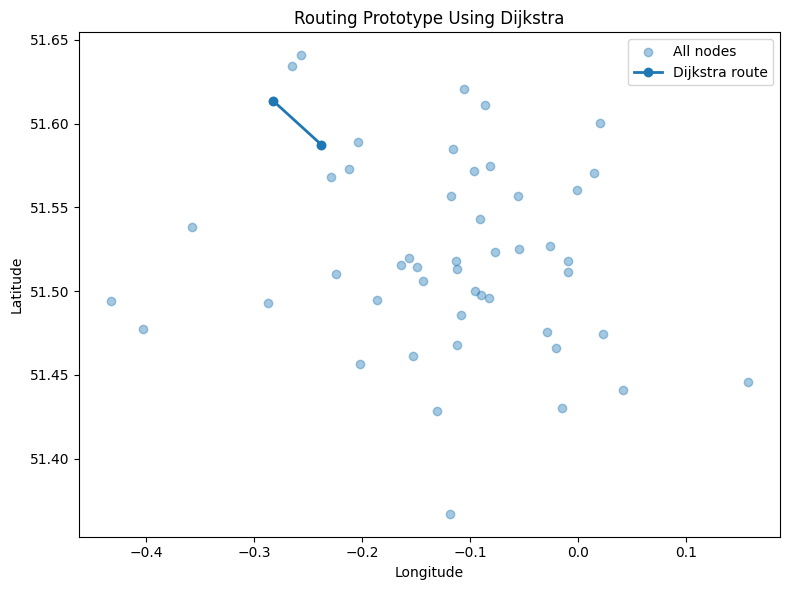

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(sample_nodes["longitude"], sample_nodes["latitude"], alpha=0.4, label="All nodes")
plt.plot(route_df["longitude"], route_df["latitude"], marker="o", linewidth=2, label="Dijkstra route")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Routing Prototype Using Dijkstra")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
start_node = sample_nodes.iloc[0]["count_point_id"]
end_node = sample_nodes.iloc[40]["count_point_id"]

print("Start node:", start_node)
print("End node:", end_node)

path = nx.shortest_path(G, source=start_node, target=end_node, weight="weight")
path_length = nx.shortest_path_length(G, source=start_node, target=end_node, weight="weight")

print("Shortest path:", path)
print("Weighted path cost:", path_length)

Start node: 6000.0
End node: 6459.0
Shortest path: [np.float64(6000.0), np.float64(6151.0), np.float64(6428.0), np.float64(6121.0), np.float64(6459.0)]
Weighted path cost: 0.1903583277460604


In [33]:
route_df = sample_nodes[sample_nodes["count_point_id"].isin(path)].copy()
route_df["route_order"] = route_df["count_point_id"].apply(lambda x: path.index(x))
route_df = route_df.sort_values("route_order")

print(route_df)

    count_point_id   latitude  longitude  all_motor_vehicles  route_order
0             6000  51.587522  -0.237927         1536.903226            0
21            6151  51.568052  -0.228869          958.061404            1
37            6428  51.509986  -0.224638          499.000000            2
17            6121  51.494742  -0.186334         1477.728856            3
40            6459  51.519726  -0.156512          718.259259            4


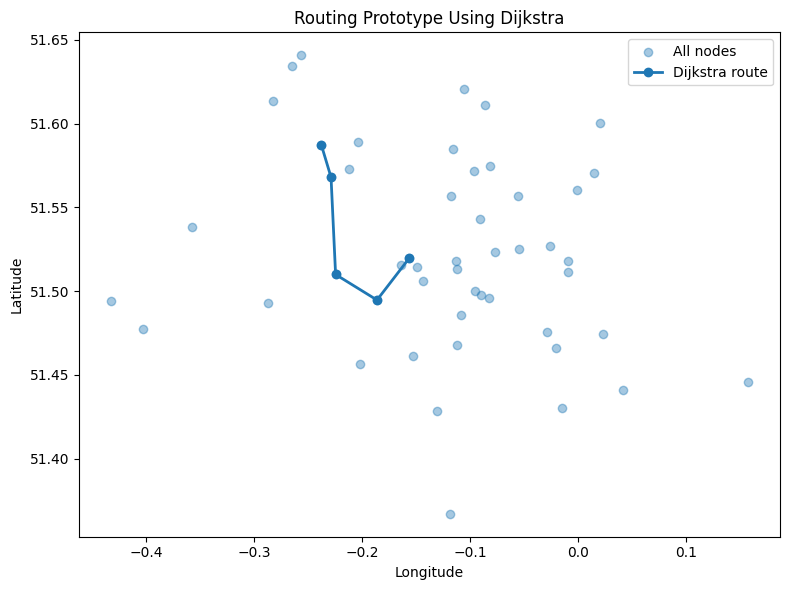

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(sample_nodes["longitude"], sample_nodes["latitude"], alpha=0.4, label="All nodes")
plt.plot(route_df["longitude"], route_df["latitude"], marker="o", linewidth=2, label="Dijkstra route")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Routing Prototype Using Dijkstra")
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
from pathlib import Path

output_path = Path("../outputs")
output_path.mkdir(exist_ok=True)

edges_df.to_csv(output_path / "routing_edges.csv", index=False)
route_df.to_csv(output_path / "routing_route.csv", index=False)

print("Routing outputs saved.")

Routing outputs saved.


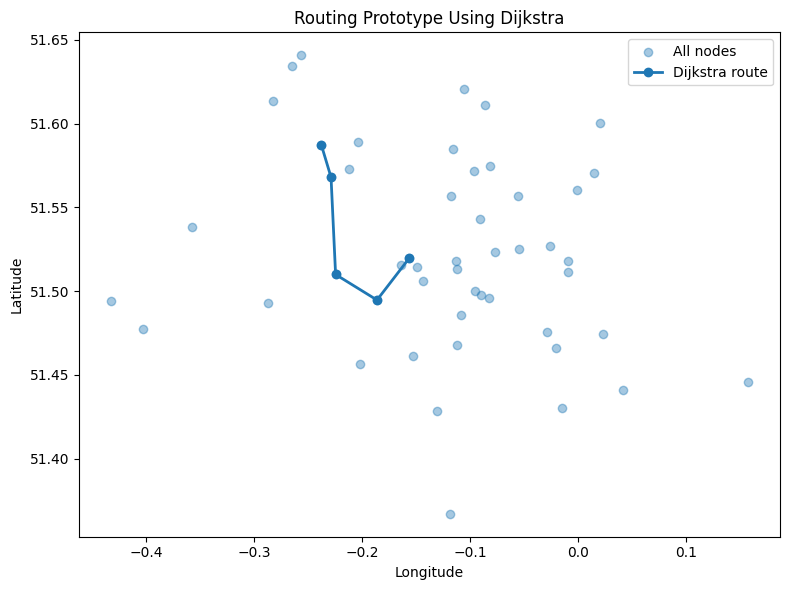

In [36]:
plt.figure(figsize=(8,6))
plt.scatter(sample_nodes["longitude"], sample_nodes["latitude"], alpha=0.4, label="All nodes")
plt.plot(route_df["longitude"], route_df["latitude"], marker="o", linewidth=2, label="Dijkstra route")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Routing Prototype Using Dijkstra")
plt.legend()
plt.tight_layout()
plt.savefig(output_path / "routing_prototype.png", dpi=300, bbox_inches="tight")
plt.show()